# Regresja liniowa

Notebook pokazuje najprostszy pelny proces:
1. import bibliotek
2. wczytanie danych CSV
3. sprawdzenie danych
4. podzial na trening i test
5. trenowanie modelu
6. predykcja
7. wykres: ceny rzeczywiste vs przewidywane
8. testowanie modelu dla recznie podanych parametrow

## 1) Import bibliotek

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline


## 2) Wczytanie danych

In [30]:
df = pd.read_csv("b.csv",sep=';',decimal=',')
df.head()

,metraz_m2,pietro,rok_budowy,standard,odleglosc_km,cena_tys_pln
0,80,6,2012,3,4.1,667
1,53,4,1972,4,8.1,404
2,54,3,1993,3,3.7,461
3,92,4,1986,3,4.9,727
4,63,0,2009,4,8.5,493


## 3) Sprawdzenie wczytanych danych

In [31]:
print("Rozmiar danych:", df.shape)
print("\nTypy kolumn:")
print(df.dtypes)
print("\nPodstawowe statystyki:")
df.describe()

print(df.columns)

Rozmiar danych: (260, 6)

Typy kolumn:
metraz_m2         int64
pietro            int64
rok_budowy        int64
standard          int64
odleglosc_km    float64
cena_tys_pln      int64
dtype: object

Podstawowe statystyki:
Index(['metraz_m2', 'pietro', 'rok_budowy', 'standard', 'odleglosc_km',
       'cena_tys_pln'],
      dtype='str')


## 4) Podzial na dane treningowe i testowe

In [32]:
feature_cols = ['metraz_m2', 'pietro', 'rok_budowy', 'standard', 'odleglosc_km']
X = df[feature_cols]
y = df["cena_tys_pln"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

print("X_train:", X_train.shape, "X_test:", X_test.shape)

X_train: (195, 5) X_test: (65, 5)


## 5) Trenowanie modelu

In [42]:
def build_model(degree=None):
    if degree is None:
        return LinearRegression()
    else:
        return Pipeline([
            ("poly", PolynomialFeatures(degree=degree, include_bias=False)),
            ("model", LinearRegression())
        ])

In [58]:

model = build_model(2)   # regresja kwadratowa

model.fit(X_train, y_train)

print("Model wytrenowany.")

Model wytrenowany.


## 6) Predykcja i prosta ocena modelu

In [59]:
y_pred = model.predict(X_test)
r2 = model.score(X_test, y_test)
print(f"R2 na zbiorze testowym: {r2:.4f}")

porownanie = pd.DataFrame({"cena_rzeczywista": y_test.values, "cena_przewidywana": y_pred})
porownanie.head()

R2 na zbiorze testowym: 0.9823


,cena_rzeczywista,cena_przewidywana
0,426,450.617025
1,765,771.904370
2,556,573.791502
3,458,459.160183
4,437,426.199303


## 7) Wykres: predykcja i ceny rzeczywiste

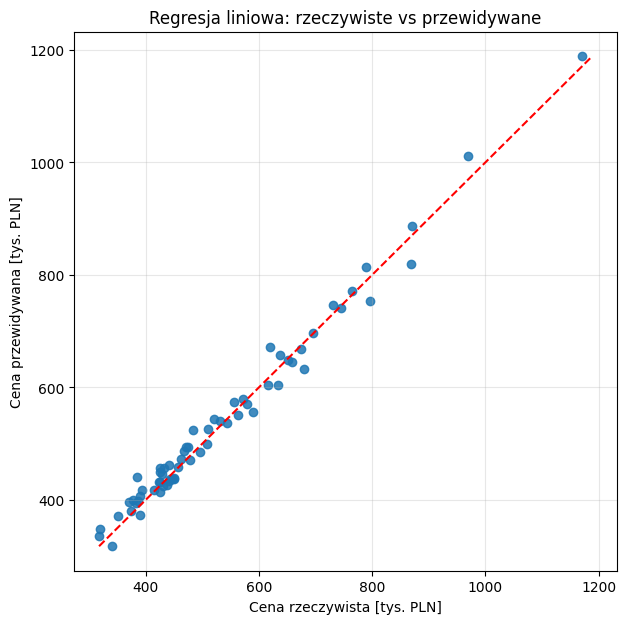

In [60]:
plt.figure(figsize=(7, 7))
plt.scatter(y_test, y_pred, alpha=0.85)

min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], "r--")

plt.xlabel("Cena rzeczywista [tys. PLN]")
plt.ylabel("Cena przewidywana [tys. PLN]")
plt.title("Regresja liniowa: rzeczywiste vs przewidywane")
plt.grid(True, alpha=0.3)
plt.show()



## 8) Zapisanie modelu do pliku

In [29]:
import pickle

with open("model_cena_mieszkan.pkl", "wb") as f:
    pickle.dump(model, f)
